# 05 — Demo Sidang

**Skripsi:** Implementasi *Time Series Foundation Model* Chronos-2 untuk Peramalan Probabilistik Harga Perak dengan Variabel Kovariat Harga Emas dan Dollar Index

Notebook ini adalah **demo ringkas untuk pembimbing dan penguji**. Seluruh sel dirancang selesai berjalan **di bawah 5 menit pada laptop tanpa GPU**: tidak ada pengunduhan data, tidak ada perhitungan Mutual Information ulang, tidak ada fine-tuning, dan tidak ada evaluasi ulang seluruh periode uji. Satu-satunya komputasi model yang benar-benar dijalankan di sini adalah **tiga jendela ramalan zero-shot** — cukup untuk membuktikan pipeline hidup, dan cukup murah untuk dijalankan di depan penguji.

## Alur sistem

```
1  PENGUMPULAN DATA        SI=F (perak, target), GC=F (emas), DX-Y.NYB (dolar)
   src/data_collection.py  Yahoo Finance, harian, END_DATE dikunci di config
          |                (bukan today(), supaya hasil reproducible)
          v
2  PREPROCESSING           outer join per tanggal -> forward fill -> BUANG baris
   src/preprocessing.py    yang nilai targetnya hasil ffill, supaya tidak muncul
          |                segmen datar buatan yang menaikkan akurasi semu
          v
3  PEMBAGIAN DATA          kronologis, tanpa acak: 70% latih / 15% validasi / 15% uji
   src/preprocessing.py    latih -> fine-tuning; validasi -> pemilihan hyperparameter;
          |                uji -> pelaporan akhir, disentuh SATU KALI
          v
4  MUTUAL INFORMATION      dihitung HANYA dari data latih, dua varian wajib:
   src/mutual_information  level harga dan log-return (+ uji permutasi)
          |
          v
5  PERAMALAN               a. Zero-shot  : Chronos-2 apa adanya, tanpa pelatihan
   src/forecasting.py      b. Fine-tuned : hyperparameter dipilih di data VALIDASI
   src/baseline.py         c. Naive      : baseline persistence (penyebut MASE)
          |                kovariat = PAST-ONLY, known_covariates_names = []
          v
6  EVALUASI                rolling origin expanding: H = 10 hari perdagangan,
   src/evaluation.py       stride = 1, ketiga skema pada jendela yang PERSIS SAMA
          |                metrik titik  : MAE, RMSE, MAPE, MASE
          |                probabilistik : CRPS, cakupan 80%/95%, lebar interval,
          |                                quantile crossing rate
          |                signifikansi  : Diebold-Mariano + HAC Newey-West (lag H-1)
          v
7  PELAPORAN               results/metrics/*.json + results/figures/*.png
   src/visualization.py    dibaca ulang oleh notebook 04 dan notebook ini
```

**Titik paling kritis.** Harga emas dan dolar **di masa depan tidak diketahui** pada saat peramalan dilakukan. Karena itu keduanya diberikan ke Chronos-2 sebagai *past-only covariates*: `known_covariates_names` sengaja dibiarkan **kosong**. Bila nilai masa depan kovariat ikut diberikan, model "mengintip" masa depan dan seluruh hasil penelitian menjadi tidak sah. Skenario itu tetap dijalankan, tetapi terpisah dan berlabel **oracle / ex-post** pada analisis sensitivitas.

In [1]:
import json
import sys
import time
from pathlib import Path

# Penanda waktu untuk membuktikan klaim "selesai di bawah 5 menit" (dicetak di bagian 6)
DEMO_STARTED_AT = time.perf_counter()

# Tambahkan akar project ke sys.path agar `import src.*` bekerja dari folder notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

# Seluruh logika diimpor dari src/. Impor `src.forecasting` ikut menarik
# autogluon.timeseries -- itulah sel paling lambat di notebook ini (sekitar 10 detik),
# dan sengaja diletakkan paling depan supaya sisa demo terasa responsif.
from src.data_collection import DATE_INDEX_NAME
from src.evaluation import find_quantile_index, interval_indices, mae
from src.forecasting import load_forecast_arrays, load_processed_frames, to_model_tsdf
from src.mutual_information import build_interpretation, build_markdown_tables
from src.preprocessing import get_covariate_columns, get_target_column
from src.utils import load_config, resolve_path
from src.visualization import select_example_windows

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

CONFIG = load_config()
HORIZON = CONFIG["model"]["prediction_length"]
MAX_CONTEXT = CONFIG["model"]["max_context"]
QUANTILE_LEVELS = CONFIG["model"]["quantile_levels"]
FIGURE_DPI = CONFIG["visualization"]["figure_dpi"]
TARGET_COL = get_target_column(CONFIG)
COVARIATE_COLS = get_covariate_columns(CONFIG)

PROCESSED_DIR = resolve_path(CONFIG["data"]["processed_dir"])
METRICS_DIR = resolve_path(CONFIG["paths"]["metrics_dir"])
FIGURES_DIR = resolve_path(CONFIG["paths"]["figures_dir"])
FORECASTS_DIR = resolve_path(CONFIG["paths"]["forecasts_dir"])
MODELS_DIR = resolve_path(CONFIG["paths"]["models_dir"])

# Palet dan label dibuat sama dengan src/visualization.py agar gambar demo ini
# tampak berasal dari sistem visual yang sama dengan gambar laporan.
SCHEME_LABELS = {
    "naive": "Naive Persistence",
    "zeroshot": "Chronos-2 Zero-Shot",
    "finetuned": "Chronos-2 Fine-Tuned",
}
SCHEME_COLORS = {"naive": "#898781", "zeroshot": "#2a78d6", "finetuned": "#eb6834"}
SCHEME_ORDER = ("naive", "zeroshot", "finetuned")
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE, GRIDLINE = "#fcfcfb", "#e1e0d9"

print("Target            :", TARGET_COL)
print("Kovariat          :", ", ".join(COVARIATE_COLS), "(past-only)")
print("Horizon H         :", HORIZON, "hari perdagangan")
print("Jumlah kuantil    :", len(QUANTILE_LEVELS))
print("Akar project      :", PROJECT_ROOT)

Target            : silver_close
Kovariat          : gold_close, dxy_close (past-only)
Horizon H         : 10 hari perdagangan
Jumlah kuantil    : 13
Akar project      : D:\project-skripsi


## 0. Pemeriksaan prasyarat

Notebook ini **tidak menghasilkan** angka apa pun dari nol: ia membaca keluaran `run_pipeline.py`. Sel berikut memeriksa lebih dulu bahwa seluruh berkas yang dibutuhkan sudah ada, lalu berhenti dengan pesan yang jelas bila ada yang hilang — supaya kegagalan tidak muncul sebagai `KeyError` di tengah demo.

Berkas dibagi dua: **wajib** (tanpa ini demo tidak bisa jalan) dan **opsional** (predictor zero-shot tersimpan; bila tidak ada, bagian 3 otomatis beralih ke ramalan arsip dan sisa notebook tetap berjalan).

In [2]:
REQUIRED_FILES = {
    "Data latih terproses": PROCESSED_DIR / "train.csv",
    "Data validasi terproses": PROCESSED_DIR / "val.csv",
    "Data uji terproses": PROCESSED_DIR / "test.csv",
    "Hasil Mutual Information": METRICS_DIR / "mutual_information.json",
    "Hasil akhir evaluasi": METRICS_DIR / "final_results.json",
    "Gambar MI (barplot)": FIGURES_DIR / "mi_barplot.png",
}
for scheme in SCHEME_ORDER:
    REQUIRED_FILES[f"Ramalan uji - {SCHEME_LABELS[scheme]}"] = (
        FORECASTS_DIR / f"{scheme}_H{HORIZON}.parquet"
    )

OPTIONAL_FILES = {
    "Predictor zero-shot tersimpan": MODELS_DIR / f"chronos2_zeroshot_H{HORIZON}",
}

print(f"{'Berkas':<44}{'Status':<12}Lokasi")
print("-" * 100)

missing = [label for label, path in REQUIRED_FILES.items() if not path.exists()]
for label, path in REQUIRED_FILES.items():
    status = "ADA" if path.exists() else "HILANG"
    print(f"{label:<44}{status:<12}{path.relative_to(PROJECT_ROOT)}")
for label, path in OPTIONAL_FILES.items():
    status = "ADA" if path.exists() else "(opsional, tidak ada)"
    print(f"{label:<44}{status:<12}{path.relative_to(PROJECT_ROOT)}")

if missing:
    raise FileNotFoundError(
        "Berkas hasil pipeline berikut belum ada: "
        + ", ".join(missing)
        + ".\n\n"
        "Jalankan `python run_pipeline.py` terlebih dahulu dari akar project, "
        "lalu jalankan ulang notebook ini.\n"
        "Bila data mentah sudah terunduh, cukup `python run_pipeline.py --skip-download`.\n"
        "Catatan: tahap peramalan menyentuh data uji dan hanya boleh dijalankan "
        "sekali untuk pelaporan akhir, agar tidak terjadi kebocoran data."
    )

print()
print("Seluruh prasyarat wajib tersedia. Demo dapat dilanjutkan.")

Berkas                                      Status      Lokasi
----------------------------------------------------------------------------------------------------
Data latih terproses                        ADA         data\processed\train.csv
Data validasi terproses                     ADA         data\processed\val.csv
Data uji terproses                          ADA         data\processed\test.csv
Hasil Mutual Information                    ADA         results\metrics\mutual_information.json
Hasil akhir evaluasi                        ADA         results\metrics\final_results.json
Gambar MI (barplot)                         ADA         results\figures\mi_barplot.png
Ramalan uji - Naive Persistence             ADA         results\forecasts\naive_H10.parquet
Ramalan uji - Chronos-2 Zero-Shot           ADA         results\forecasts\zeroshot_H10.parquet
Ramalan uji - Chronos-2 Fine-Tuned          ADA         results\forecasts\finetuned_H10.parquet
Predictor zero-shot tersimpan          

## 1. Data yang sudah diproses

Data dibaca dari `data/processed/` — **tidak ada pengunduhan ulang** dari Yahoo Finance. Ketiga bagian disatukan kembali menjadi satu deret utuh karena protokol rolling origin memakai konteks *expanding*: konteks sebuah jendela uji boleh mencakup seluruh riwayat sebelumnya, tetapi berhenti tepat satu langkah sebelum origin sehingga tidak mungkin ada kebocoran.

In [3]:
FRAMES = load_processed_frames(("train", "val", "test"), config=CONFIG)
FULL_DF = pd.concat([FRAMES[name] for name in ("train", "val", "test")])
FULL_DF.index.name = DATE_INDEX_NAME

# Posisi baris pertama periode uji pada deret utuh -- dipakai bagian 3 dan 5.
EVAL_START_IDX = len(FRAMES["train"]) + len(FRAMES["val"])

split_summary = pd.DataFrame(
    [
        {
            "Bagian": name.capitalize(),
            "Baris": len(frame),
            "Porsi (%)": 100 * len(frame) / len(FULL_DF),
            "Tanggal awal": frame.index[0].date(),
            "Tanggal akhir": frame.index[-1].date(),
            "Perak awal (USD)": frame[TARGET_COL].iloc[0],
            "Perak akhir (USD)": frame[TARGET_COL].iloc[-1],
        }
        for name, frame in FRAMES.items()
    ]
).set_index("Bagian")

display(split_summary)

print(f"Deret utuh   : {len(FULL_DF)} hari perdagangan "
      f"({FULL_DF.index[0].date()} s.d. {FULL_DF.index[-1].date()})")
print(f"Kolom        : {list(FULL_DF.columns)}")
for column in COVARIATE_COLS:
    flag = f"{column.split('_')[0]}_ffilled"
    if flag in FULL_DF.columns:
        print(f"Forward fill : {flag} = {int(FULL_DF[flag].sum())} baris "
              f"(kovariat boleh di-ffill; nilai target TIDAK)")

2026-08-19 09:00:58 | INFO     | forecasting | Memuat train: 879 baris (2021-08-16 s.d. 2025-02-12)


2026-08-19 09:00:58 | INFO     | forecasting | Memuat val  : 188 baris (2025-02-13 s.d. 2025-11-10)


2026-08-19 09:00:58 | INFO     | forecasting | Memuat test : 190 baris (2025-11-11 s.d. 2026-08-14)


,Baris,Porsi (%),Tanggal awal,Tanggal akhir,Perak awal (USD),Perak akhir (USD)
Bagian,,,,,,
Train,879,69.9284,2021-08-16,2025-02-12,23.7800,32.6950
Val,188,14.9562,2025-02-13,2025-11-10,32.6500,50.1770
Test,190,15.1154,2025-11-11,2026-08-14,50.6180,64.9880


Deret utuh   : 1257 hari perdagangan (2021-08-16 s.d. 2026-08-14)
Kolom        : ['silver_close', 'gold_close', 'dxy_close', 'gold_ffilled', 'dxy_ffilled']
Forward fill : gold_ffilled = 0 baris (kovariat boleh di-ffill; nilai target TIDAK)
Forward fill : dxy_ffilled = 1 baris (kovariat boleh di-ffill; nilai target TIDAK)


## 2. Mutual Information — dibaca dari JSON, tidak dihitung ulang

Angka di bawah ini diambil apa adanya dari `results/metrics/mutual_information.json`. Perhitungannya mahal (uji permutasi 1.000 kali x 20 pengulangan estimator k-NN) dan **hanya memakai data latih**, jadi tidak ada alasan menghitungnya ulang saat sidang. Tabelnya disusun oleh `build_markdown_tables()` dari `src/mutual_information.py` — fungsi yang sama persis yang dipakai pipeline, bukan tabel yang ditulis ulang di notebook.

Dua varian dilaporkan berdampingan dengan sengaja: MI pada **level harga** cenderung *overestimate* karena kedua deret sama-sama bertren, sedangkan MI pada **log-return** adalah angka yang secara statistik sah untuk mengklaim ketergantungan.

In [4]:
with (METRICS_DIR / "mutual_information.json").open("r", encoding="utf-8") as file:
    mi_results = json.load(file)

print("Sumber        :", mi_results["data"]["source"])
print("Keputusan     :", mi_results["decision"])
print("Sampel        :", mi_results["data"]["n_rows"], "baris",
      f"({mi_results['data']['date_start']} s.d. {mi_results['data']['date_end']})")
print("Estimator     :", mi_results["settings"]["estimator"],
      f"| k = {mi_results['settings']['n_neighbors']}",
      f"| {mi_results['settings']['n_repeats']} pengulangan",
      f"| {mi_results['settings']['n_permutations']} permutasi")
print("Dihitung pada :", mi_results["generated_at"])

display(Markdown(build_markdown_tables(mi_results["results"], mi_results["lagged"])))

Sumber        : data/processed/train.csv
Keputusan     : MI dihitung hanya dari data latih (mencegah kebocoran data)
Sampel        : 879 baris (2021-08-16 s.d. 2025-02-12)
Estimator     : sklearn.feature_selection.mutual_info_regression (k-NN) | k = 3 | 20 pengulangan | 1000 permutasi
Dihitung pada : 2026-08-18T01:08:56


### Tabel 1. Mutual Information dan korelasi perak vs kovariat (data latih)

| Varian | Kovariat | n | MI (nat) | SD MI | Pearson r | Spearman rho | p (permutasi) |
|---|---|---:|---:|---:|---:|---:|---:|
| Level harga | GOLD | 879 | 1.3477 | 0.0003 | +0.9324 | +0.8464 | 0.0010 |
| Level harga | DXY | 879 | 0.7753 | 0.0007 | -0.0187 | -0.1533 | 0.0010 |
| Log-return | GOLD | 878 | 0.4150 | 0.0000 | +0.7785 | +0.7546 | 0.0010 |
| Log-return | DXY | 878 | 0.0899 | 0.0002 | -0.4063 | -0.3959 | 0.0010 |

### Tabel 2. Mutual Information menurut lag kovariat (data latih)

| Varian | Kovariat | lag 0 | lag 1 | lag 2 | lag 3 | lag 5 |
|---|---|---:|---:|---:|---:|---:|
| Level harga | GOLD | 1.3477 | 1.1654 | 1.1262 | 1.1075 | 1.1337 |
| Level harga | DXY | 0.7753 | 0.6932 | 0.6338 | 0.6606 | 0.6761 |
| Log-return | GOLD | 0.4150 | 0.0000 | 0.0000 | 0.0000 | 0.0048 |
| Log-return | DXY | 0.0899 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |

*MI dalam satuan nat; seluruh angka dihitung hanya dari data latih.*

Pada level harga MI perak terhadap kovariat mencapai GOLD = 1.348 dan DXY = 0.775 nat, sedangkan pada log-return turun menjadi GOLD = 0.415 dan DXY = 0.090 nat — yakni 3.2 sampai 8.6 kali lebih kecil. Meski begitu kedua kovariat layak dipakai: uji permutasi pada log-return menolak hipotesis kemandirian untuk keduanya (p <= 0.001), dan DXY bahkan menyimpan MI 0.775 nat pada level padahal korelasi Pearson-nya hanya -0.019, pertanda keterkaitannya tidak tertangkap ukuran linear. Di sisi lain MI log-return runtuh menjadi paling besar 0.005 nat begitu lag >= 1 (dari 0.415 nat pada lag 0), sehingga kovariat bersifat sezaman dan bukan penunjuk arah (lead) bagi perak; manfaatnya bagi Chronos-2 karena itu terletak pada pengayaan konteks past-only, bukan pada kemampuan meramal beberapa hari ke depan dari kovariat saja. MI level jauh lebih besar karena harga perak, emas, dan dolar sama-sama merupakan proses non-stasioner yang berbagi tren jangka panjang: pada level estimator k-NN sesungguhnya mengukur kesamaan lintasan tren, bukan keterkaitan pergerakan harian, sehingga MI level melebih-lebihkan kandungan informasi yang benar-benar dapat dieksploitasi untuk peramalan.

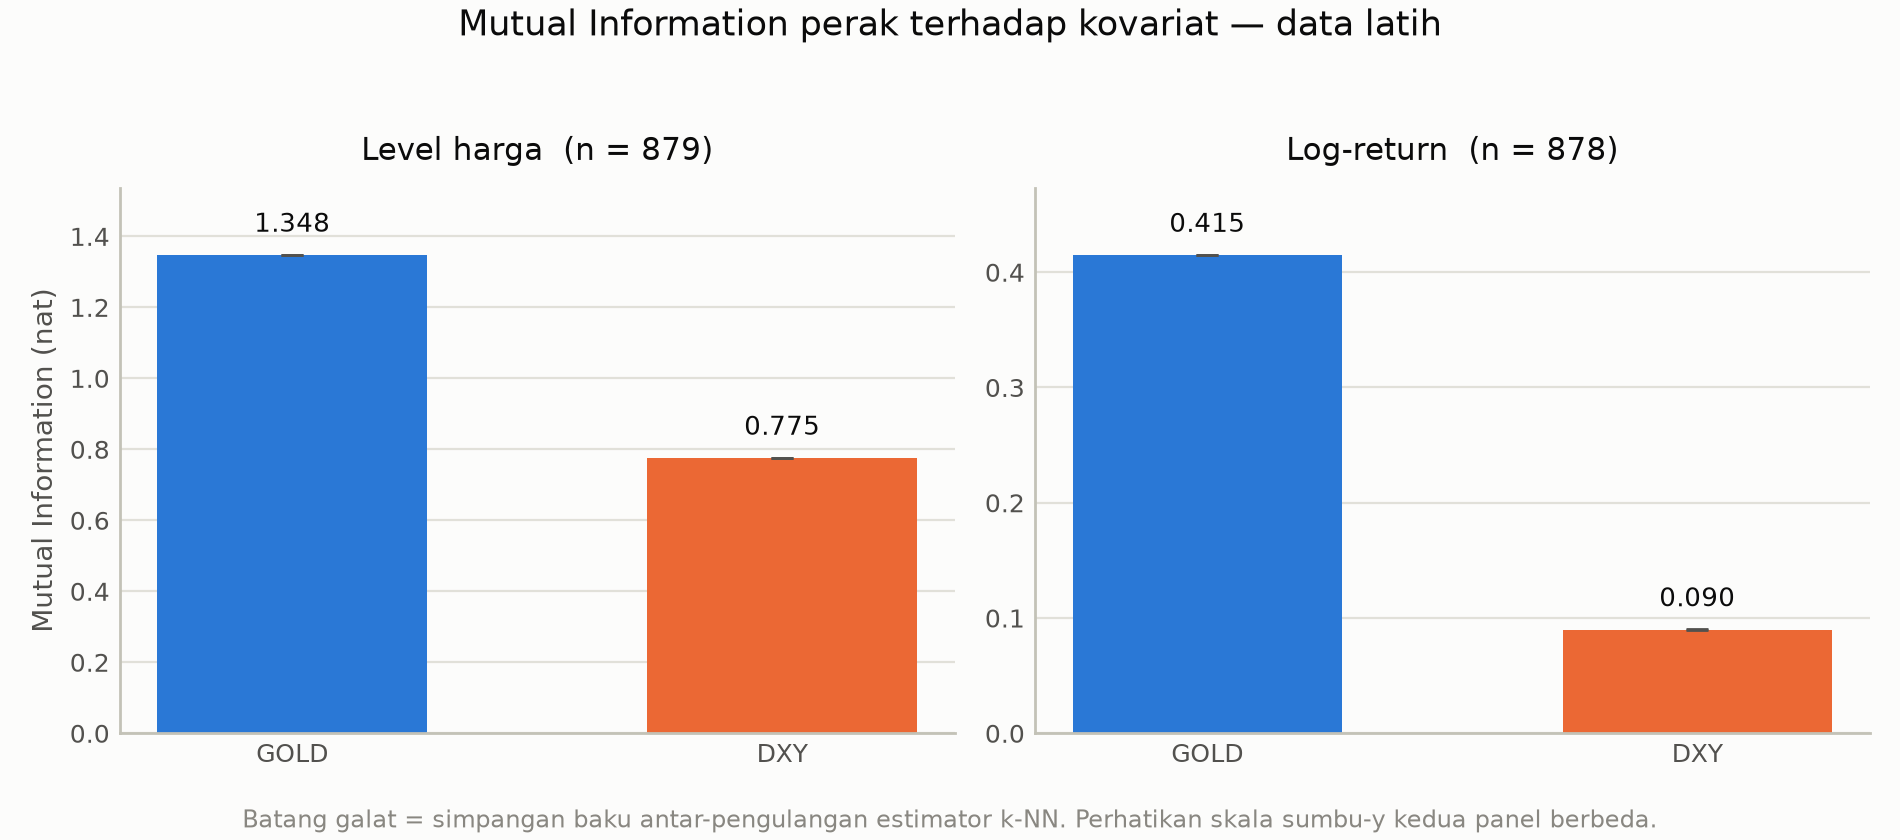

In [5]:
display(Markdown(build_interpretation(mi_results["results"], mi_results["lagged"])))
Image(filename=str(FIGURES_DIR / "mi_barplot.png"))

## 3. Demo *live*: ramalan zero-shot untuk 3 jendela

Bagian inilah yang benar-benar menjalankan Chronos-2 di depan penguji. Yang dilakukan:

1. Predictor zero-shot **dimuat dari disk** (`results/models/chronos2_zeroshot_H10`) — bukan dibangun ulang. Pada skema zero-shot tidak ada satu pun bobot yang dilatih, jadi memuatnya sudah cukup.
2. Dipilih **3 jendela** dari jendela resmi periode uji memakai `select_example_windows()` milik `src/visualization.py`: awal, tengah, dan akhir periode uji. Pemilihannya deterministik dan tidak melihat galat, jadi bukan etalase kasus terbaik.
3. Untuk tiap jendela: konteks dipotong sampai tepat sebelum origin (dibatasi `max_context`), lalu `predictor.predict()` dipanggil **tanpa** argumen `known_covariates`, sehingga nilai emas dan dolar di masa depan tidak pernah sampai ke model.

**Ini bukan evaluasi baru atas data uji.** Jendela yang dipakai persis jendela yang sudah dievaluasi `run_pipeline.py`, seluruh prosesnya deterministik (`random_seed = 42`), dan tidak ada satu pun keputusan model yang diambil dari hasilnya. Sel verifikasi di akhir bagian ini membandingkan keluaran *live* terhadap `results/forecasts/zeroshot_H10.parquet` — selisihnya harus **nol**, dan itulah bukti reproducibility yang ingin ditunjukkan.

In [6]:
from autogluon.timeseries import TimeSeriesPredictor

ZEROSHOT_MODEL_PATH = MODELS_DIR / f"chronos2_zeroshot_H{HORIZON}"
LIVE_PREDICTOR = None

# Pemuatan bobot adalah langkah paling lambat pada demo ini (sekitar 45 detik di CPU).
# Bila gagal -- misal artefak predictor belum ada, atau bobot Chronos-2 belum tersedia
# di cache HuggingFace pada laptop yang dipakai -- demo TIDAK berhenti: bagian
# berikutnya beralih ke ramalan arsip, dan peralihan itu dinyatakan terbuka.
try:
    started = time.perf_counter()
    LIVE_PREDICTOR = TimeSeriesPredictor.load(str(ZEROSHOT_MODEL_PATH))
    LIVE_PREDICTOR.persist()
    print(f"Predictor dimuat dalam {time.perf_counter() - started:.1f} detik")
    print("Model             :", LIVE_PREDICTOR.model_names())
    print("prediction_length :", LIVE_PREDICTOR.prediction_length)
    print("known_covariates  :", LIVE_PREDICTOR.known_covariates_names,
          "<-- WAJIB KOSONG: kovariat hanya dibaca sebagai masa lalu")
except Exception as error:  # noqa: BLE001 -- demo tidak boleh mati di depan penguji
    LIVE_PREDICTOR = None
    print("GAGAL memuat predictor zero-shot:")
    print(f"   {type(error).__name__}: {error}")
    print()
    print("Demo dilanjutkan memakai ramalan arsip dari "
          f"results/forecasts/zeroshot_H{HORIZON}.parquet.")
    print("Untuk memulihkan mode live, jalankan `python run_pipeline.py --skip-download` "
          "agar artefak predictor terbentuk ulang.")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 5421.06it/s]

Predictor dimuat dalam 13.6 detik
Model             : ['Chronos2ZeroShot']
prediction_length : 10
known_covariates  : [] <-- WAJIB KOSONG: kovariat hanya dibaca sebagai masa lalu


In [7]:
# Ramalan resmi yang tersimpan -- dipakai sebagai pembanding verifikasi, sekaligus
# cadangan bila predictor gagal dimuat.
STORED_ZEROSHOT = load_forecast_arrays("zeroshot", horizon=HORIZON, split="test", config=CONFIG)
N_WINDOWS = len(STORED_ZEROSHOT["origins"])
DEMO_WINDOWS = select_example_windows(N_WINDOWS, CONFIG["visualization"]["n_example_windows"])

predict_columns = [str(level) for level in QUANTILE_LEVELS]
live_quantiles = np.empty((len(DEMO_WINDOWS), HORIZON, len(QUANTILE_LEVELS)), dtype=float)
live_actual = np.empty((len(DEMO_WINDOWS), HORIZON), dtype=float)
live_seconds = []

target_values = FULL_DF[TARGET_COL].to_numpy(dtype=float)

print(f"{N_WINDOWS} jendela resmi tersedia; yang diramalkan pada demo ini: "
      f"indeks jendela {DEMO_WINDOWS}")
print()
print(f"{'Jendela':>8}{'Origin':>8}  {'Konteks s.d.':<14}{'Sasaran H langkah':<28}"
      f"{'Waktu':>9}  Sumber")
print("-" * 92)

for row, window in enumerate(DEMO_WINDOWS):
    origin = int(STORED_ZEROSHOT["origins"][window])
    target_dates = FULL_DF.index[origin : origin + HORIZON]
    live_actual[row] = target_values[origin : origin + HORIZON]

    started = time.perf_counter()
    if LIVE_PREDICTOR is not None:
        context_frame = FULL_DF.iloc[max(0, origin - MAX_CONTEXT) : origin]
        context_tsdf = to_model_tsdf(context_frame, CONFIG, end_position=origin)
        # known_covariates sengaja TIDAK diteruskan: nilai masa depan kovariat
        # tidak diketahui saat peramalan dilakukan
        prediction = LIVE_PREDICTOR.predict(context_tsdf, random_seed=CONFIG["seed"])
        live_quantiles[row] = prediction[predict_columns].to_numpy(dtype=float)
        source = "live (predict)"
    else:
        live_quantiles[row] = STORED_ZEROSHOT["y_pred_quantiles"][window]
        source = "arsip (parquet)"
    elapsed = time.perf_counter() - started
    live_seconds.append(elapsed)

    span = f"{target_dates[0].date()} s.d. {target_dates[-1].date()}"
    print(f"{window:>8}{origin:>8}  {str(FULL_DF.index[origin - 1].date()):<14}{span:<28}"
          f"{elapsed:>7.1f} d  {source}")

print("-" * 92)
print(f"Total {sum(live_seconds):.1f} detik untuk {len(DEMO_WINDOWS)} jendela "
      f"({sum(live_seconds) / len(DEMO_WINDOWS):.1f} detik per jendela)")

181 jendela resmi tersedia; yang diramalkan pada demo ini: indeks jendela [0, 90, 180]

 Jendela  Origin  Konteks s.d.  Sasaran H langkah               Waktu  Sumber
--------------------------------------------------------------------------------------------


       0    1067  2025-11-10    2025-11-11 s.d. 2025-11-24      1.9 d  live (predict)


      90    1157  2026-03-23    2026-03-24 s.d. 2026-04-07      0.3 d  live (predict)


     180    1247  2026-07-31    2026-08-03 s.d. 2026-08-14      0.3 d  live (predict)
--------------------------------------------------------------------------------------------
Total 2.5 detik untuk 3 jendela (0.8 detik per jendela)


In [8]:
# Verifikasi: keluaran live harus identik dengan ramalan resmi pada jendela yang sama.
print(f"{'Jendela':>8}{'Origin (tanggal)':>20}{'Selisih maks (USD)':>22}   Status")
print("-" * 72)
for row, window in enumerate(DEMO_WINDOWS):
    difference = float(
        np.abs(live_quantiles[row] - STORED_ZEROSHOT["y_pred_quantiles"][window]).max()
    )
    if difference == 0.0:
        status = "identik"
    elif difference < 1e-6:
        status = "praktis identik"
    else:
        status = "BERBEDA - periksa versi library"
    origin_date = pd.Timestamp(STORED_ZEROSHOT["origin_dates"][window]).date()
    print(f"{window:>8}{str(origin_date):>20}{difference:>22.3e}   {status}")
print("-" * 72)

if LIVE_PREDICTOR is None:
    print("Mode arsip: verifikasi di atas trivial, karena angkanya memang berasal")
    print("dari berkas yang sama.")
else:
    print("Ramalan yang baru saja dihitung sama persis dengan yang dilaporkan pada BAB IV.")
    print("Inilah arti 'reproducible' pada penelitian ini: seed dikunci, END_DATE dikunci,")
    print("dan seluruh keputusan model tersimpan di disk, sehingga angka yang sama dapat")
    print("dibangkitkan ulang kapan saja.")

 Jendela    Origin (tanggal)    Selisih maks (USD)   Status
------------------------------------------------------------------------
       0          2025-11-11             0.000e+00   identik
      90          2026-03-24             0.000e+00   identik
     180          2026-08-03             0.000e+00   identik
------------------------------------------------------------------------
Ramalan yang baru saja dihitung sama persis dengan yang dilaporkan pada BAB IV.
Inilah arti 'reproducible' pada penelitian ini: seed dikunci, END_DATE dikunci,
dan seluruh keputusan model tersimpan di disk, sehingga angka yang sama dapat
dibangkitkan ulang kapan saja.


## 4. Tabel hasil akhir

Seluruh angka dibaca dari `results/metrics/final_results.json` — keluaran tahap 5 `run_pipeline.py`. Tidak ada metrik yang dihitung ulang di notebook ini.

Cara membacanya: **MASE < 1** berarti mengungguli baseline naive persistence pada jendela yang sama. **Cakupan** interval 80% dan 95% wajib dibaca berpasangan dengan **lebar interval** — cakupan tinggi yang dicapai lewat interval kelewat lebar bukan kalibrasi yang baik. Dan yang paling menentukan: **selisih angka antar skema baru boleh dinarasikan sebagai keunggulan bila uji Diebold-Mariano menyatakannya signifikan.**

In [9]:
with (METRICS_DIR / "final_results.json").open("r", encoding="utf-8") as file:
    final_results = json.load(file)

protocol = final_results["protocol"]
print("Protokol evaluasi rolling origin")
print(f"  Horizon H          : {protocol['horizon']} hari perdagangan")
print(f"  Stride             : {protocol['stride']}")
print(f"  Jumlah jendela     : {protocol['n_windows']} (identik untuk seluruh skema)")
print(f"  Periode uji        : {protocol['test_start']} s.d. {protocol['test_end']}")
print(f"  Konteks            : {protocol['context_type']}")
print(f"  known_covariates   : {protocol['known_covariates_names']} (kovariat past-only)")

selection = final_results["finetune_selection"]
print()
print("Hyperparameter fine-tuning terpilih (dari data VALIDASI saja)")
print(f"  {selection['best_params']}")
print(f"  {selection['selection_metric']} validasi = {selection['best_val_score']:.6f} "
      f"| {selection['n_candidates']} kandidat diuji, {selection['n_failed']} gagal")

rows = []
for scheme in SCHEME_ORDER:
    overall = final_results["metrics"][scheme]["overall"]
    rows.append({
        "Skema": SCHEME_LABELS[scheme],
        "MAE": overall["mae"],
        "RMSE": overall["rmse"],
        "MAPE (%)": overall["mape"],
        "MASE": overall["mase"],
        "CRPS": overall["crps"],
        "nCRPS": overall["normalized_crps"],
        "Cov80": overall["coverage"]["0.8"],
        "Cov95": overall["coverage"]["0.95"],
        "Width80": overall["interval_width"]["0.8"],
        "Crossing": overall["quantile_crossing_rate"],
    })

display(pd.DataFrame(rows).set_index("Skema"))

Protokol evaluasi rolling origin
  Horizon H          : 10 hari perdagangan
  Stride             : 1
  Jumlah jendela     : 181 (identik untuk seluruh skema)
  Periode uji        : 2025-11-11 s.d. 2026-08-03
  Konteks            : expanding (seluruh riwayat sampai origin, dibatasi max_context)
  known_covariates   : [] (kovariat past-only)

Hyperparameter fine-tuning terpilih (dari data VALIDASI saja)
  {'fine_tune_lr': 0.0001, 'fine_tune_steps': 200, 'fine_tune_mode': 'lora'}
  WQL validasi = 0.009882 | 18 kandidat diuji, 0 gagal


,MAE,RMSE,MAPE (%),MASE,CRPS,nCRPS,Cov80,Cov95,Width80,Crossing
Skema,,,,,,,,,,
Naive Persistence,5.6810,8.2954,7.5106,1.0000,3.6997,0.0511,0.7680,0.9149,19.6722,0.0000
Chronos-2 Zero-Shot,6.0303,9.1035,7.9775,1.0615,3.8774,0.0535,0.6801,0.9094,14.8809,0.0000
Chronos-2 Fine-Tuned,6.0315,9.0039,7.9800,1.0617,3.9114,0.0540,0.6707,0.8939,14.7890,0.0000


In [10]:
alpha = CONFIG["evaluation"]["diebold_mariano"]["alpha"]

dm_table = pd.DataFrame(final_results["diebold_mariano"])[
    ["label", "primary", "mean_loss_differential", "statistic", "p_value", "hac_lag",
     "significant"]
].rename(columns={
    "label": "Perbandingan",
    "primary": "Uji utama",
    "mean_loss_differential": "Selisih rugi",
    "statistic": "Statistik DM",
    "p_value": "p-value",
    "hac_lag": "Lag HAC",
    "significant": "Signifikan",
}).set_index("Perbandingan")
display(dm_table)

print(f"Kesimpulan uji signifikansi (alfa = {alpha:g}):")
for test in final_results["diebold_mariano"]:
    penanda = " [UJI UTAMA]" if test["primary"] else ""
    if test["significant"]:
        kalimat = (
            f"SIGNIFIKAN (p = {test['p_value']:.4f}); "
            f"{SCHEME_LABELS.get(test['better_scheme'], test['better_scheme'])} lebih akurat."
        )
    else:
        kalimat = (f"tidak signifikan (p = {test['p_value']:.4f}); kedua skema tidak "
                   "terbukti berbeda akurasinya.")
    print(f"  - {test['label']}{penanda}: {kalimat}")

,Uji utama,Selisih rugi,Statistik DM,p-value,Lag HAC,Signifikan
Perbandingan,,,,,,
Chronos-2 Zero-Shot vs Chronos-2 Fine-Tuned,True,-0.0012,-0.0123,0.9902,9,False
Chronos-2 Zero-Shot vs Naive Persistence,False,0.3493,1.2688,0.2045,9,False
Chronos-2 Fine-Tuned vs Naive Persistence,False,0.3505,1.5871,0.1125,9,False


Kesimpulan uji signifikansi (alfa = 0.05):
  - Chronos-2 Zero-Shot vs Chronos-2 Fine-Tuned [UJI UTAMA]: tidak signifikan (p = 0.9902); kedua skema tidak terbukti berbeda akurasinya.
  - Chronos-2 Zero-Shot vs Naive Persistence: tidak signifikan (p = 0.2045); kedua skema tidak terbukti berbeda akurasinya.
  - Chronos-2 Fine-Tuned vs Naive Persistence: tidak signifikan (p = 0.1125); kedua skema tidak terbukti berbeda akurasinya.


## 5. Gambar ringkasan: ramalan vs aktual beserta pita ketidakpastian

Satu gambar untuk menjawab pertanyaan "jadi hasilnya seperti apa?".

**Panel atas** menempatkan ketiga jendela demo pada lini masa harga perak yang sesungguhnya, sehingga terlihat di titik mana ramalan itu dibuat dan sebesar apa jendela 10 hari dibanding pergerakan harga secara keseluruhan. **Tiga panel bawah** memperbesar tiap jendela: garis putus-putus adalah harga aktual, garis tebal adalah median ramalan, dan dua lapis pita adalah interval 80% dan 95%.

Yang layak diperhatikan penguji: pita **melebar seiring bertambahnya horizon** — model menyatakan ketidakpastiannya sendiri secara eksplisit, dan justru itulah nilai tambah peramalan probabilistik dibanding satu angka titik.

Tersimpan: results\figures\demo_sidang_ringkasan.png


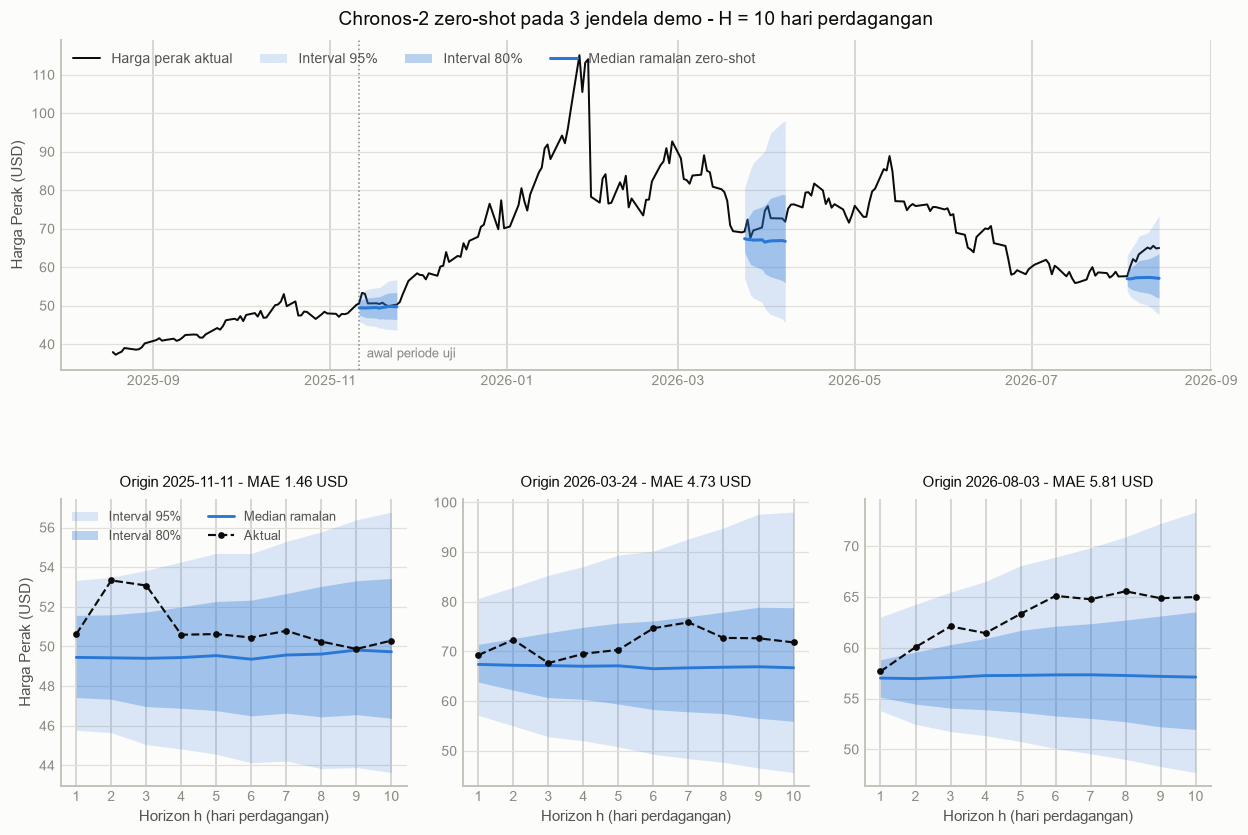

In [11]:
median_index = find_quantile_index(QUANTILE_LEVELS, CONFIG["evaluation"]["point_quantile"])
low_80, high_80 = interval_indices(QUANTILE_LEVELS, 0.80)
low_95, high_95 = interval_indices(QUANTILE_LEVELS, 0.95)
color = SCHEME_COLORS["zeroshot"]


def style_axes(ax):
    """Gaya sumbu seragam dengan gambar-gambar pada src/visualization.py."""
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c3c2b7")
    ax.tick_params(colors=INK_MUTED, labelsize=9, length=0)


figure = plt.figure(figsize=(13.5, 8.8), facecolor=SURFACE)
grid = figure.add_gridspec(2, 3, height_ratios=[1.15, 1.0], hspace=0.42, wspace=0.16)

# --- Panel atas: lini masa harga aktual + ketiga jendela demo -----------------
ax_timeline = figure.add_subplot(grid[0, :])
style_axes(ax_timeline)

timeline = FULL_DF.iloc[max(0, EVAL_START_IDX - 60) :]
ax_timeline.plot(timeline.index, timeline[TARGET_COL], color=INK_PRIMARY,
                 linewidth=1.3, label="Harga perak aktual", zorder=4)
ax_timeline.axvline(FULL_DF.index[EVAL_START_IDX], color=INK_MUTED, linewidth=1.0,
                    linestyle=":", zorder=3)
ax_timeline.annotate("awal periode uji", xy=(FULL_DF.index[EVAL_START_IDX], 0),
                     xycoords=("data", "axes fraction"), xytext=(5, 8),
                     textcoords="offset points", fontsize=8.5, color=INK_MUTED)

for row, window in enumerate(DEMO_WINDOWS):
    origin = int(STORED_ZEROSHOT["origins"][window])
    dates = FULL_DF.index[origin : origin + HORIZON]
    quantiles = live_quantiles[row]
    ax_timeline.fill_between(dates, quantiles[:, low_95], quantiles[:, high_95],
                             color=color, alpha=0.16, linewidth=0, zorder=5,
                             label="Interval 95%" if row == 0 else None)
    ax_timeline.fill_between(dates, quantiles[:, low_80], quantiles[:, high_80],
                             color=color, alpha=0.32, linewidth=0, zorder=6,
                             label="Interval 80%" if row == 0 else None)
    ax_timeline.plot(dates, quantiles[:, median_index], color=color, linewidth=2.0,
                     zorder=7, label="Median ramalan zero-shot" if row == 0 else None)

ax_timeline.set_title(
    f"Chronos-2 zero-shot pada {len(DEMO_WINDOWS)} jendela demo "
    f"- H = {HORIZON} hari perdagangan",
    fontsize=12.5, color=INK_PRIMARY, pad=10)
ax_timeline.set_ylabel("Harga Perak (USD)", fontsize=9.5, color=INK_SECONDARY)
ax_timeline.legend(frameon=False, fontsize=9, loc="upper left",
                   labelcolor=INK_SECONDARY, ncol=4)

# --- Panel bawah: perbesaran tiap jendela ------------------------------------
steps = np.arange(1, HORIZON + 1)
for row, window in enumerate(DEMO_WINDOWS):
    ax = figure.add_subplot(grid[1, row])
    style_axes(ax)
    quantiles, actual = live_quantiles[row], live_actual[row]

    ax.fill_between(steps, quantiles[:, low_95], quantiles[:, high_95], color=color,
                    alpha=0.16, linewidth=0, label="Interval 95%", zorder=2)
    ax.fill_between(steps, quantiles[:, low_80], quantiles[:, high_80], color=color,
                    alpha=0.32, linewidth=0, label="Interval 80%", zorder=3)
    ax.plot(steps, quantiles[:, median_index], color=color, linewidth=1.9,
            label="Median ramalan", zorder=4)
    ax.plot(steps, actual, color=INK_PRIMARY, linewidth=1.4, linestyle="--", marker="o",
            markersize=3.4, label="Aktual", zorder=5)

    origin_date = pd.Timestamp(STORED_ZEROSHOT["origin_dates"][window]).date()
    # mae() menuntut bentuk (n_windows, H); satu jendela ditambahi sumbu jendela.
    window_mae = mae(actual[np.newaxis, :], quantiles[np.newaxis, :, median_index])
    ax.set_title(f"Origin {origin_date} - MAE {window_mae:.2f} USD",
                 fontsize=10, color=INK_PRIMARY, pad=8)
    ax.set_xlabel("Horizon h (hari perdagangan)", fontsize=9.5, color=INK_SECONDARY)
    ax.set_xticks(steps)
    if row == 0:
        ax.set_ylabel("Harga Perak (USD)", fontsize=9.5, color=INK_SECONDARY)
        ax.legend(frameon=False, fontsize=8.5, loc="best", labelcolor=INK_SECONDARY,
                  ncol=2)

summary_path = FIGURES_DIR / "demo_sidang_ringkasan.png"
figure.savefig(summary_path, dpi=FIGURE_DPI, bbox_inches="tight", facecolor=SURFACE)
print("Tersimpan:", summary_path.relative_to(PROJECT_ROOT))
plt.show()

## 6. Penutup

Pokok yang ditunjukkan demo ini:

1. **Alurnya utuh dan modular** — pengumpulan data, preprocessing, mutual information, peramalan, evaluasi, visualisasi; masing-masing satu modul di `src/` dan semuanya dapat dijalankan mandiri.
2. **Tidak ada kebocoran data.** Kovariat bersifat *past-only* (`known_covariates_names = []`), konteks tiap jendela berhenti tepat sebelum origin, hyperparameter fine-tuning dipilih hanya dari data validasi, dan data uji disentuh sekali oleh `run_pipeline.py`.
3. **Reproducible.** Ramalan yang dihitung *live* pada bagian 3 sama persis dengan angka BAB IV, karena seed dan `END_DATE` dikunci di `config/config.yaml`.
4. **Jujur soal signifikansi.** Selisih MAE/CRPS antar skema dilaporkan bersama uji Diebold-Mariano ber-HAC; selisih yang tidak signifikan tidak dinarasikan sebagai keunggulan.

Materi pendukung bila penguji ingin menggali lebih jauh:

| Pertanyaan | Berkas |
|---|---|
| Bagaimana perilaku data mentahnya? | `notebooks/01_eda_data.ipynb` |
| Kenapa emas dan dolar yang dipilih? | `notebooks/02_mutual_information.ipynb` |
| Bagaimana API Chronos-2 diverifikasi? | `notebooks/03_chronos2_smoke_test.ipynb` |
| Seluruh tabel dan gambar BAB IV | `notebooks/04_hasil_evaluasi.ipynb` |
| Apakah kesimpulan bertahan pada H lain? | `results/metrics/sensitivity_summary.md` |

In [12]:
elapsed_total = time.perf_counter() - DEMO_STARTED_AT
print(f"Total waktu jalan notebook demo : {elapsed_total:.1f} detik "
      f"({elapsed_total / 60:.1f} menit)")
print("Anggaran                        : 300 detik (5 menit) di laptop tanpa GPU")
print("Status                          :",
      "MEMENUHI" if elapsed_total < 300 else "MELEBIHI ANGGARAN")

if LIVE_PREDICTOR is not None:
    # Melepas bobot dari memori supaya kernel tidak menahan model setelah demo selesai.
    LIVE_PREDICTOR.unpersist()
    print()
    print("Bobot model dilepas dari memori.")

Total waktu jalan notebook demo : 25.3 detik (0.4 menit)
Anggaran                        : 300 detik (5 menit) di laptop tanpa GPU
Status                          : MEMENUHI

Bobot model dilepas dari memori.
